Name: Vanchanagiri Alekhya
---
Enrollment Number: MML2025002
---
GenAI & LLMS Assignment-8
---

In [ ]:

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN, GRU, LSTM
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import os
import re
import time
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)



Data Preprocessing
---

In [ ]:

import subprocess

DATA_DIR = "/content/nottingham-dataset/ABC_cleaned"

if not os.path.exists("nottingham-dataset"):
    print("Cloning Nottingham dataset...")
    subprocess.run(["git", "clone", "https://github.com/jukedeck/nottingham-dataset"], check=True)
    print("Dataset downloaded ")
else:
    print("Dataset already exists ")

abc_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.abc')]


###  Loading ABC Files


In [ ]:


def load_abc_data(data_dir):

    all_text = ""
    loaded = 0
    for file in sorted(os.listdir(data_dir)):
        if file.endswith(".abc"):
            with open(os.path.join(data_dir, file), 'r', encoding='utf-8', errors='ignore') as f:
                all_text += f.read() + "\n"
            loaded += 1
    print(f"Loaded {loaded} files | Total characters: {len(all_text):,}")
    return all_text

raw_text = load_abc_data(DATA_DIR)
print("\nSample (first 300 chars):\n")
print(raw_text[:300])

Loaded 14 files | Total characters: 446,034

Sample (first 300 chars):


X: 1
T:A and A's Waltz
% Nottingham Music Database
S:Mick Peat
M:3/4
L:1/4
K:G
e|:"G"d2B|"D"A3/2B/2c|"G"B2G|"D"A2e|"G"d2B|"D"A3/2B/2c|
M:2/4
"F"B=F|
M:3/4
"G"G2e:||:
"C"g2e|"Bb"=f2d|"F"c2A|=F2e|"C"g2e|"Bb"=f2d|
M:2/4
"F"cA|
M:3/4
 [1 "G"G2e:| [2"G"G2z||


X: 2
T:Barry's Favourite
% Nottingham Music


###  Preprocess ABC Notation


In [ ]:

print("=== FIRST 500 CHARS OF RAW TEXT ===")
print(repr(raw_text[:500]))

print("\n=== FIRST 10 LINES ===")
for i, line in enumerate(raw_text.splitlines()[:10]):
    print(f"{i:02d}: {repr(line)}")

print("\n=== LINES CONTAINING 'X:' ===")
x_lines = [l for l in raw_text.splitlines() if l.startswith('X:')]
print(f"Found {len(x_lines)} X: lines. First 5: {x_lines[:5]}")

print("\n=== LINES CONTAINING 'K:' ===")
k_lines = [l for l in raw_text.splitlines() if l.startswith('K:')]
print(f"Found {len(k_lines)} K: lines. First 5: {k_lines[:5]}")

=== FIRST 500 CHARS OF RAW TEXT ===
'\nX: 1\nT:A and A\'s Waltz\n% Nottingham Music Database\nS:Mick Peat\nM:3/4\nL:1/4\nK:G\ne|:"G"d2B|"D"A3/2B/2c|"G"B2G|"D"A2e|"G"d2B|"D"A3/2B/2c|\nM:2/4\n"F"B=F|\nM:3/4\n"G"G2e:||:\n"C"g2e|"Bb"=f2d|"F"c2A|=F2e|"C"g2e|"Bb"=f2d|\nM:2/4\n"F"cA|\nM:3/4\n [1 "G"G2e:| [2"G"G2z||\n\n\nX: 2\nT:Barry\'s Favourite\n% Nottingham Music Database\nS:Mick Peat\nM:2/2\nK:D\nA2|:"D"a3/2b/2a3/2g/2 f2(3def|"Em"g3/2a/2g3/2f/2 "A"e2A2|"D"f3/2g/2f3/2e/2 d2f2\\\n|"Em"B3/2c/2d3/2e/2 "A"c2A2|\n"D"a3/2b/2a3/2g/2 f2(3def|"Em"g3/2a/2g3/2f/2 "A"e2A2|\\\n"D"'

=== FIRST 10 LINES ===
00: ''
01: 'X: 1'
02: "T:A and A's Waltz"
03: '% Nottingham Music Database'
04: 'S:Mick Peat'
05: 'M:3/4'
06: 'L:1/4'
07: 'K:G'
08: 'e|:"G"d2B|"D"A3/2B/2c|"G"B2G|"D"A2e|"G"d2B|"D"A3/2B/2c|'
09: 'M:2/4'

=== LINES CONTAINING 'X:' ===
Found 1034 X: lines. First 5: ['X: 1', 'X: 2', 'X: 3', 'X: 4', 'X: 5']

=== LINES CONTAINING 'K:' ===
Found 1148 K: lines. First 5: ['K:G', 'K:D', 'K:A', 'K:D', 'K:G']


In [ ]:

import os

print(f"DATA_DIR = '{DATA_DIR}'")
print(f"Does it exist? {os.path.exists(DATA_DIR)}")
print()

search_dirs = ['.', '..', '/content', '/content/drive/MyDrive',
               os.path.expanduser('~'), '/tmp']

for d in search_dirs:
    if os.path.exists(d):
        for root, dirs, files in os.walk(d):
            abc_files = [f for f in files if f.endswith('.abc')]
            if abc_files:
                print(f"Found .abc files in: {root}")
                print(f"  Files: {abc_files[:5]}")

DATA_DIR = '/content/nottingham-dataset/ABC_cleaned'
Does it exist? True

Found .abc files in: ./nottingham-dataset/ABC_cleaned
  Files: ['waltzes.abc', 'xmas.abc', 'hpps.abc', 'reelsa-c.abc', 'jigs.abc']
Found .abc files in: ./nottingham-dataset/ABC_original
  Files: ['waltzes.abc', 'xmas.abc', 'hpps.abc', 'reelsa-c.abc', 'jigs.abc']
Found .abc files in: ../usr/local/lib/python3.12/dist-packages/music21/corpus/josquin
  Files: ['milleRegrets.abc', 'petiteCamusette.abc', 'fortunaDunGranTempo.abc', 'laDeplorationDeLaMorteDeJohannesOckeghem.abc', 'oVenusBant.abc']
Found .abc files in: ../usr/local/lib/python3.12/dist-packages/music21/corpus/airdsAirs
  Files: ['book4.abc', 'book5.abc', 'book2.abc', 'book1.abc', 'book3.abc']
Found .abc files in: ../usr/local/lib/python3.12/dist-packages/music21/corpus/ryansMammoth
  Files: ['SukeyBidsMeReel.abc', 'NewCenturyHornpipe.abc', 'ManchesterReel.abc', 'MaggieBrownsFavoriteJig.abc', 'CampMeetingJigNo2.abc']
Found .abc files in: ../usr/local/lib/py

In [ ]:

def preprocess_abc_data(text):

    processed_tunes = []

    tune_blocks = re.split(r'(?=^X:)', text, flags=re.MULTILINE)

    for block in tune_blocks:
        if not block.strip():
            continue

        k_match = re.search(r'^K:.*$', block, flags=re.MULTILINE)
        if not k_match:
            continue

        body = block[k_match.end():]

        cleaned = re.sub(r'%.*$', '', body, flags=re.MULTILINE)

        cleaned = re.sub(r'\s+', ' ', cleaned).strip()

        if len(cleaned) > 20:
            processed_tunes.append(cleaned)

    return processed_tunes

tunes = preprocess_abc_data(raw_text)
print(f"Extracted {len(tunes)} tunes after preprocessing")
print(f"Average tune length: {np.mean([len(t) for t in tunes]):.0f} chars")
print(f"\nExample tune (first 200 chars):\n{tunes[0][:200]}")

Extracted 1034 tunes after preprocessing
Average tune length: 339 chars

Example tune (first 200 chars):
e|:"G"d2B|"D"A3/2B/2c|"G"B2G|"D"A2e|"G"d2B|"D"A3/2B/2c| M:2/4 "F"B=F| M:3/4 "G"G2e:||: "C"g2e|"Bb"=f2d|"F"c2A|=F2e|"C"g2e|"Bb"=f2d| M:2/4 "F"cA| M:3/4 [1 "G"G2e:| [2"G"G2z||


###  Build Vocabulary & Character Mappings


In [ ]:


combined_text = ' '.join(tunes)
chars = sorted(list(set(combined_text)))
VOCAB_SIZE = len(chars)

char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

print(f"Vocabulary size: {VOCAB_SIZE} unique characters")
print(f"Characters: {''.join(chars)}")

Vocabulary size: 58 unique characters
Characters:  !"#'()+,-/0123456789:=ABCDEFGHKLMPQSV[\]^_abcdefgilmrtz|~


###  Training Sequences

In [ ]:


SEQ_LENGTH = 64

def create_sequences(texts, seq_length, char_to_idx, vocab_size):
    sequences = []
    next_chars = []

    for text in texts:
        for i in range(0, len(text) - seq_length):
            sequences.append(text[i : i + seq_length])
            next_chars.append(text[i + seq_length])

    print(f"Total training sequences: {len(sequences):,}")

    X = np.zeros((len(sequences), seq_length), dtype=np.int32)
    y = np.zeros((len(sequences), vocab_size), dtype=np.float32)

    for i, (seq, nchar) in enumerate(zip(sequences, next_chars)):
        for t, char in enumerate(seq):
            X[i, t] = char_to_idx.get(char, 0)
        y[i, char_to_idx.get(nchar, 0)] = 1.0

    return X, y

X, y = create_sequences(tunes, SEQ_LENGTH, char_to_idx, VOCAB_SIZE)
print(f"X shape: {X.shape} | y shape: {y.shape}")

split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]
print(f"Train: {X_train.shape[0]:,} sequences | Validation: {X_val.shape[0]:,} sequences")

Total training sequences: 284,114
X shape: (284114, 64) | y shape: (284114, 58)
Train: 227,291 sequences | Validation: 56,823 sequences


---
##  Model Implementation

### Build RNN / GRU / LSTM Models


In [ ]:

EMBEDDING_DIM = 128
RNN_UNITS     = 256

def build_model(model_type, vocab_size=VOCAB_SIZE, seq_length=SEQ_LENGTH,
                embedding_dim=EMBEDDING_DIM, rnn_units=RNN_UNITS):

    model = Sequential(name=model_type.upper())

    model.add(Embedding(vocab_size, embedding_dim, input_length=seq_length,
                        name='embedding'))

    if model_type == 'rnn':
        model.add(SimpleRNN(rnn_units, return_sequences=False, name='vanilla_rnn'))
    elif model_type == 'gru':
        model.add(GRU(rnn_units, return_sequences=False, name='gru'))
    elif model_type == 'lstm':
        model.add(LSTM(rnn_units, return_sequences=False, name='lstm'))

    model.add(Dense(vocab_size, activation='softmax', name='output'))

    model.compile(loss='categorical_crossentropy', optimizer='adam',
                  metrics=['accuracy'])
    return model


rnn_model  = build_model('rnn')
gru_model  = build_model('gru')
lstm_model = build_model('lstm')


### Count Parameters Comparison


In [ ]:


models_dict = {'Vanilla RNN': rnn_model, 'GRU': gru_model, 'LSTM': lstm_model}

print(f"{'Model':<15} {'Total Params':>15} {'Trainable Params':>18}")
print("-" * 52)
for name, model in models_dict.items():
    model.build(input_shape=(None, SEQ_LENGTH))
    total     = model.count_params()
    trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f"{name:<15} {total:>15,} {trainable:>18,}")

Model              Total Params   Trainable Params
----------------------------------------------------
Vanilla RNN             120,890            120,890
GRU                     318,778            318,778
LSTM                    416,570            416,570


---
##  Training and Evaluation

###  Training Loop with Timing
#### Train all three models with identical hyperparameters. Record training time and history for comparison.

In [ ]:

EPOCHS     = 30
BATCH_SIZE = 128

os.makedirs("checkpoints", exist_ok=True)

histories    = {}
train_times  = {}

for name, model in models_dict.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)

    model_key = name.lower().replace(' ', '_')

    callbacks = [
        ModelCheckpoint(f"checkpoints/{model_key}_best.keras",
                        save_best_only=True, monitor='val_loss', verbose=0),
        EarlyStopping(monitor='val_loss', patience=95, restore_best_weights=True, verbose=1)
    ]

    t_start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    t_end = time.time()

    histories[name]   = history
    train_times[name] = round(t_end - t_start, 2)


Training: Vanilla RNN
Epoch 1/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6707 - loss: 0.9970 - val_accuracy: 0.6402 - val_loss: 1.1684
Epoch 2/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.6719 - loss: 0.9907 - val_accuracy: 0.6376 - val_loss: 1.1825
Epoch 3/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6699 - loss: 0.9960 - val_accuracy: 0.6335 - val_loss: 1.2017
Epoch 4/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6715 - loss: 0.9951 - val_accuracy: 0.6365 - val_loss: 1.1941
Epoch 5/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6695 - loss: 0.9980 - val_accuracy: 0.6340 - val_loss: 1.2135
Epoch 6/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6593 - loss: 1.0370 - val_accuracy: 0.6240 - val_loss: 1.2300
Epoch 7/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.6609 - loss: 1.0277 - val_accuracy: 0.6318 - val_loss: 1.2122
Epoch 8/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - a

### Plot Training & Validation Loss Curves


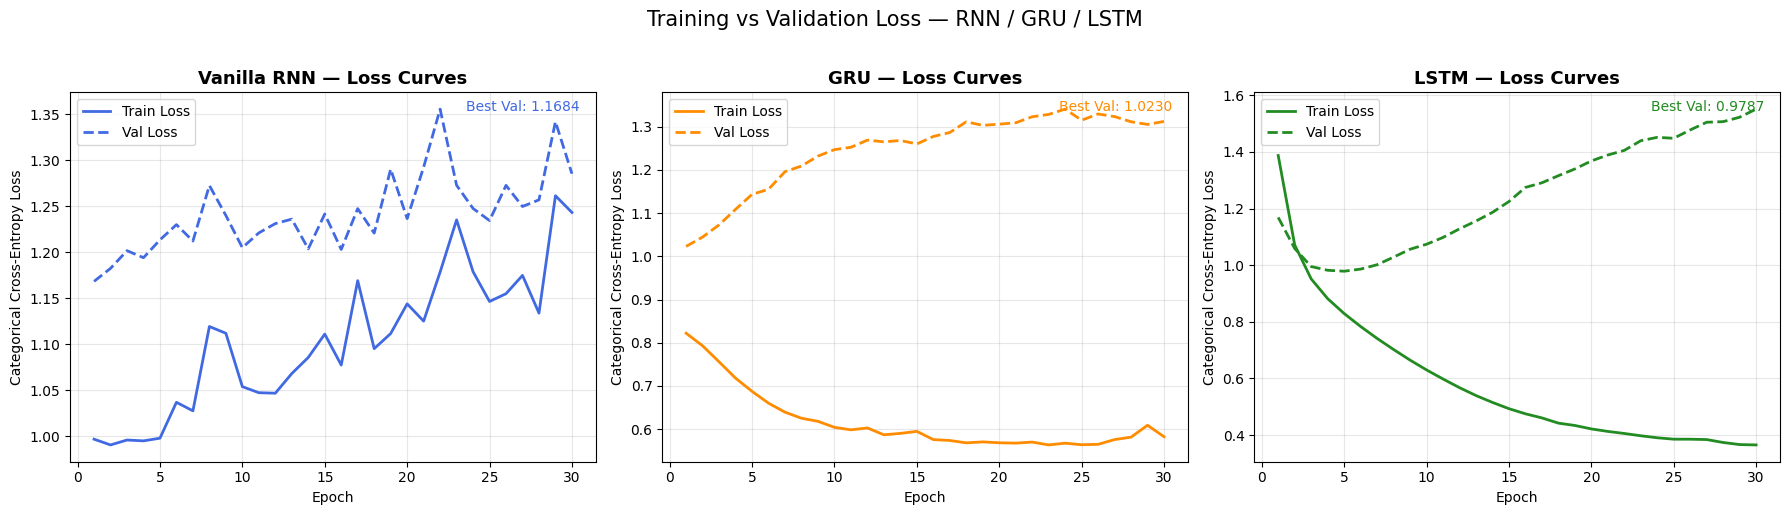

Loss curves saved as 'loss_curves.png'


In [ ]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'Vanilla RNN': 'royalblue', 'GRU': 'darkorange', 'LSTM': 'forestgreen'}

for ax, (name, history) in zip(axes, histories.items()):
    color = colors[name]
    epochs_range = range(1, len(history.history['loss']) + 1)

    ax.plot(epochs_range, history.history['loss'],     color=color, lw=2,
            label='Train Loss')
    ax.plot(epochs_range, history.history['val_loss'], color=color, lw=2,
            linestyle='--', label='Val Loss')

    ax.set_title(f'{name} — Loss Curves', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Categorical Cross-Entropy Loss')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.annotate(f"Best Val: {min(history.history['val_loss']):.4f}",
                xy=(0.97, 0.95), xycoords='axes fraction', ha='right',
                fontsize=10, color=color)

plt.suptitle('Training vs Validation Loss — RNN / GRU / LSTM', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curves saved as 'loss_curves.png'")

###  Plot Accuracy Curves


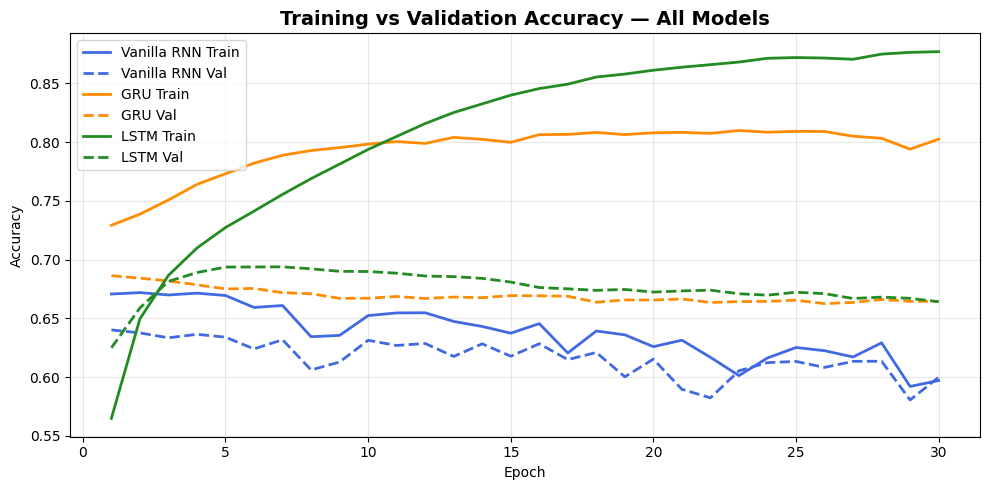

In [ ]:
plt.figure(figsize=(10, 5))

for name, history in histories.items():
    color = colors[name]
    epochs_range = range(1, len(history.history['accuracy']) + 1)
    plt.plot(epochs_range, history.history['accuracy'],     color=color, lw=2, label=f'{name} Train')
    plt.plot(epochs_range, history.history['val_accuracy'], color=color, lw=2, linestyle='--', label=f'{name} Val')

plt.title('Training vs Validation Accuracy — All Models', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()

###  Music Generation Function (Temperature Sampling)
#### Temperature controls creativity: low T → repetitive, high T → creative. Implements softmax-temperature scaling.

In [ ]:
def generate_music(model, char_to_idx, idx_to_char, seed_text,
                   num_chars=500, temperature=1.0, seq_length=SEQ_LENGTH):

    if len(seed_text) < seq_length:
        seed_text = seed_text.rjust(seq_length)
    seed_text = seed_text[-seq_length:]

    generated = seed_text

    for _ in range(num_chars):

        x_pred = np.array([[char_to_idx.get(c, 0) for c in seed_text]])

        preds = model.predict(x_pred, verbose=0)[0].astype('float64')

        log_preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(log_preds - np.max(log_preds))
        preds = exp_preds / np.sum(exp_preds)

        next_index = np.random.choice(len(preds), p=preds)
        next_char  = idx_to_char[next_index]

        generated  += next_char
        seed_text   = seed_text[1:] + next_char

    return generated

print("Generation function ready ")

###  Generate Music Samples at Multiple Temperatures
#### Run each trained model at temperatures [0.3, 0.7, 1.0, 1.5] to observe creativity-coherence trade-off.

In [ ]:


SEED_TEXT    = tunes[0][:SEQ_LENGTH]
TEMPERATURES = [0.3, 0.7, 1.0, 1.5]
GEN_LENGTH   = 300

generated_samples = {}

for name, model in models_dict.items():
    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print('='*60)
    generated_samples[name] = {}

    for temp in TEMPERATURES:
        sample = generate_music(
            model, char_to_idx, idx_to_char, SEED_TEXT,
            num_chars=GEN_LENGTH, temperature=temp
        )
        generated_samples[name][temp] = sample

        print(f"\n--- Temperature = {temp} ---")
        print(sample[SEQ_LENGTH:SEQ_LENGTH+200])


Model: Vanilla RNN

--- Temperature = 0.3 ---
"cA/2c/2 "D7"A/2B/2A/2G/2|"D"A/2B/2A/2G/2 "D7"A/2B/2c/2d/2|"A"e/2f/2e/2d/2 c/2c/2B/2A/2|"G"GB G:| P:B d|"G"g2 g2|"G"g2 gf|"A7"ee ec|"D"d3:| P:B d|"G"gg "A7"ee/2f/2|"G"g/2f/2e/2d/2 "Am"c/2B/2A/2G/2|"D"

--- Temperature = 0.7 ---
"A2D/2 A/2B/2c/2d/2|"A"ce/2f/2 f/2c/2e/2d/2|"A7"c/2d/2c/2d/2 c2|"C"e/2d/2e/2f/2 e/2f/2g/2e/2|"D"d3:| P:B e/2g/2|"D"a2 fd|"A"cA c/2B/2A/2F/2|"G"GB/2d/2 Bd| "Am"c/2d/2c/2B/2 "Bm"AB|"G"BG G:| P:B A/2G/2|

--- Temperature = 1.0 ---
"A/2B/2A/2A/2 cB/2c/2|"G"BG "Bm"FA:| P:B "C"cG GG|"D7"A/2F/2A/2B/2 "A"A_:| |:"G"g2 g|g2 g2|"Em"e3/2d/2 "Am"e/2f/2g/2e/2|\ "D"f/2d/2f/2d/2 A/2c/2B/2A/2|\ "Bm"BB/2B/2 AG|"G"G2 G2:|[2"G"G2G|"C7"G2 "G7"GF

--- Temperature = 1.5 ---
""Am/ec' ^f/2e/2d|G/2E/2E =FD| EtC(3/GAB DEFA (cdde|"G"dB2B "D/b"BGA|"Gm"B2B "D7"c2A|"G"B^cd a3"g2ga|"G"gfgf M:|| PK:F/2G/2||"GE,E E3/2F/2 BG|"Dm"A,C GC|\G/2E/2G\ G2|"A7"A2 "G"BG/2d/2|e3/2g/2 dBb\ "G"

Model: GRU

--- Temperature = 0.3 ---
"A2 "G"G2|| K:D "D"A2 F2|"D"A

###  Save Generated Samples as Text Files


In [ ]:

os.makedirs("generated_samples", exist_ok=True)

for name, temp_dict in generated_samples.items():
    for temp, sample in temp_dict.items():
        model_key = name.lower().replace(' ', '_')
        fname = f"generated_samples/{model_key}_temp{str(temp).replace('.','')}.txt"
        abc_output = f"X:1\nT:Generated by {name} (T={temp})\nM:4/4\nK:C\n{sample[SEQ_LENGTH:]}\n"
        with open(fname, 'w') as f:
            f.write(abc_output)


### Convert Generated ABC to MIDI

In [ ]:

import subprocess
import shutil

os.makedirs("midi_outputs", exist_ok=True)

abc2midi_available = shutil.which('abc2midi') is not None
print(f"abc2midi available: {abc2midi_available}")

if abc2midi_available:
    for name in models_dict:
        for temp in TEMPERATURES:
            model_key = name.lower().replace(' ', '_')
            in_file   = f"generated_samples/{model_key}_temp{str(temp).replace('.','')}.txt"
            out_file  = f"midi_outputs/{model_key}_temp{str(temp).replace('.','')}. midi"
            try:
                subprocess.run(['abc2midi', in_file, '-o', out_file], check=True, capture_output=True)
                print(f" Converted: {out_file}")
            except Exception as e:
                print(f" Skipped {in_file}: {e}")
else:

    print("abc2midi not found — generating simple MIDI files programmatically...")

    NOTE_MAP = {
        'C':60,'D':62,'E':64,'F':65,'G':67,'A':69,'B':71,
        'c':72,'d':74,'e':76,'f':77,'g':79,'a':81,'b':83
    }

    def create_simple_midi(notes, filename, tempo=120):

        import struct

        ticks_per_beat = 480
        us_per_beat = int(60_000_000 / tempo)

        def var_len(value):

            result = [value & 0x7F]
            value >>= 7
            while value:
                result.append((value & 0x7F) | 0x80)
                value >>= 7
            return bytes(reversed(result))


        events = bytearray()
        events += b'\x00\xff\x51\x03' + struct.pack('>I', us_per_beat)[1:]

        for pitch, dur_ticks in notes:
            events += var_len(0) + bytes([0x90, pitch, 80])
            events += var_len(dur_ticks) + bytes([0x80, pitch, 0])

        events += b'\x00\xff\x2f\x00'

        header = b'MThd' + struct.pack('>IHHH', 6, 0, 1, ticks_per_beat)
        track  = b'MTrk' + struct.pack('>I', len(events)) + bytes(events)

        with open(filename, 'wb') as f:
            f.write(header + track)

    for name, temp_dict in generated_samples.items():
        for temp, sample in temp_dict.items():

            note_chars = [c for c in sample[SEQ_LENGTH:] if c in NOTE_MAP]
            if not note_chars:
                note_chars = ['C'] * 20

            dur = 240
            notes_list = [(NOTE_MAP[n], dur) for n in note_chars[:100]]

            model_key = name.lower().replace(' ', '_')
            midi_path = f"midi_outputs/{model_key}_temp{str(temp).replace('.','')}.mid"
            create_simple_midi(notes_list, midi_path)


## Analysis
---




### Performance Summary Table


In [ ]:
print(f"\n{'='*75}")
print(f"{'Model':<15} {'Best Val Loss':>13} {'Best Val Acc':>13} {'Epochs':>8} {'Time (s)':>10} {'Params':>12}")
print('='*75)

for name, model in models_dict.items():
    h = histories[name].history
    best_val_loss = min(h['val_loss'])
    best_val_acc  = max(h['val_accuracy'])
    epochs_run    = len(h['loss'])
    t_time        = train_times[name]
    n_params      = model.count_params()

    print(f"{name:<15} {best_val_loss:>13.4f} {best_val_acc:>13.4f} {epochs_run:>8} {t_time:>10.1f} {n_params:>12,}")

print('='*75)


Model           Best Val Loss  Best Val Acc   Epochs   Time (s)       Params
Vanilla RNN            1.1684        0.6402       30      518.2      120,890
GRU                    1.0230        0.6863       30      690.2      318,778
LSTM                   0.9787        0.6939       30      746.8      416,570


###  Training Speed Analysis


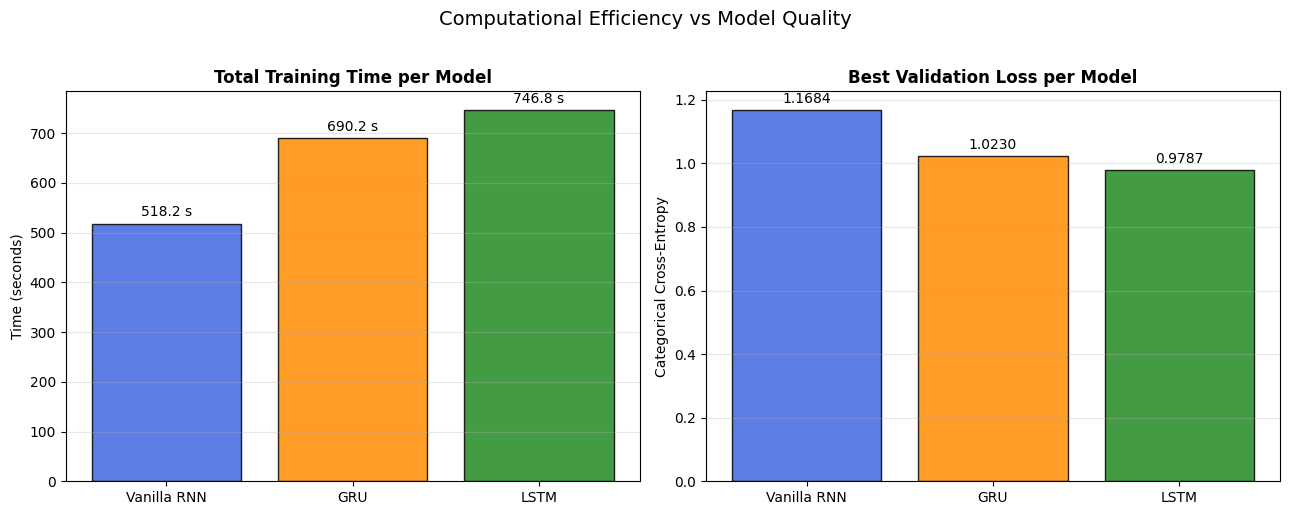

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = list(train_times.keys())
times = list(train_times.values())
bar_colors = ['royalblue', 'darkorange', 'forestgreen']

bars = axes[0].bar(model_names, times, color=bar_colors, alpha=0.85, edgecolor='black')
axes[0].bar_label(bars, fmt='%.1f s', padding=3, fontsize=10)
axes[0].set_title('Total Training Time per Model', fontweight='bold')
axes[0].set_ylabel('Time (seconds)')
axes[0].grid(axis='y', alpha=0.3)

best_losses = [min(histories[n].history['val_loss']) for n in model_names]
bars2 = axes[1].bar(model_names, best_losses, color=bar_colors, alpha=0.85, edgecolor='black')
axes[1].bar_label(bars2, fmt='%.4f', padding=3, fontsize=10)
axes[1].set_title('Best Validation Loss per Model', fontweight='bold')
axes[1].set_ylabel('Categorical Cross-Entropy')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Computational Efficiency vs Model Quality', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('efficiency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

###  Musical Structure Score

In [ ]:
def analyze_structure(text, label):
    gen_part = text[SEQ_LENGTH:]
    n = max(len(gen_part), 1)

    bar_density   = gen_part.count('|') / n * 100
    unique_ratio  = len(set(gen_part)) / VOCAB_SIZE * 100
    note_chars    = sum(1 for c in gen_part if c in 'abcdefgABCDEFG')
    note_ratio    = note_chars / n * 100

    return {'Model/Temp': label, 'Bar Density %': round(bar_density, 2),
            'Unique Chars %': round(unique_ratio, 2), 'Note Ratio %': round(note_ratio, 2)}

print(f"{'Model/Temp':<30} {'Bar Density %':>14} {'Unique Chars %':>15} {'Note Ratio %':>13}")
print('-' * 76)

for name, temp_dict in generated_samples.items():
    for temp, sample in temp_dict.items():
        label = f"{name} (T={temp})"
        metrics = analyze_structure(sample, label)
        print(f"{metrics['Model/Temp']:<30} {metrics['Bar Density %']:>14} "
              f"{metrics['Unique Chars %']:>15} {metrics['Note Ratio %']:>13}")

Model/Temp                      Bar Density %  Unique Chars %  Note Ratio %
----------------------------------------------------------------------------
Vanilla RNN (T=0.3)                      5.67           36.21         33.33
Vanilla RNN (T=0.7)                      6.33           46.55          33.0
Vanilla RNN (T=1.0)                      6.33            50.0         32.67
Vanilla RNN (T=1.5)                      7.67           62.07          46.0
GRU (T=0.3)                              8.67           34.48          41.0
GRU (T=0.7)                              7.67            43.1         36.67
GRU (T=1.0)                              7.67           51.72         33.67
GRU (T=1.5)                               6.0           68.97         35.67
LSTM (T=0.3)                             9.33           41.38         38.67
LSTM (T=0.7)                              8.0           37.93          39.0
LSTM (T=1.0)                             6.33           51.72          45.0
LSTM (T=1.5

### Convergence Rate Analysis

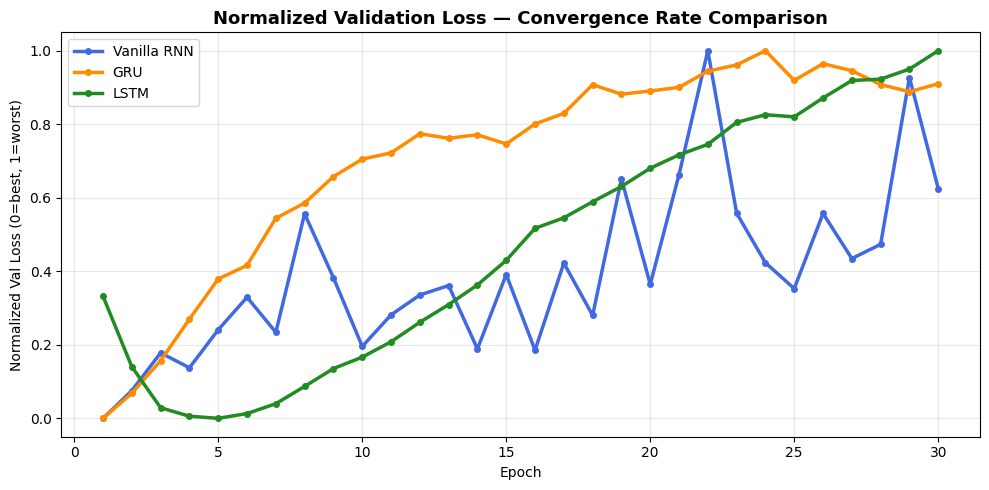

In [ ]:
plt.figure(figsize=(10, 5))

for name, history in histories.items():
    val_loss = history.history['val_loss']
    normalized = (np.array(val_loss) - min(val_loss)) / (max(val_loss) - min(val_loss) + 1e-8)
    plt.plot(range(1, len(normalized)+1), normalized,
             color=colors[name], lw=2.5, marker='o', markersize=4, label=name)

plt.title('Normalized Validation Loss — Convergence Rate Comparison', fontweight='bold', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Normalized Val Loss (0=best, 1=worst)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('convergence_rate.png', dpi=150, bbox_inches='tight')
plt.show()